In [ ]:
# SHG Intensity–Depth Analysis

# A diagnostic study supporting the main backward→forward SHG restoration project: how does SHG signal vary with tissue depth, and do the forward and backward channels behave the same way?

#  Nimo Abdinor · In2research placement 2026 · Supervised by Dr Abby Wilson

In [1]:
#Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [ ]:
# ---------------------------------------------------------------------------
# Per-slice mean intensity, with a data-quality screen and a real depth axis.
# For each file: average the 16 patches in each z-slice, flag any corrupted or
# empty/saturated slices, and convert the slice index into depth in microns.
# ---------------------------------------------------------------------------
import numpy as np

DATA_PATH = '/content/drive/MyDrive/BEng_Project/data/'
PATCHES_PER_SLICE = 16          # 1024x1024 frame -> 4x4 = 16 patches of 256x256

# full filename -> short label
FILES = {
    'F+B+lambda first 100 um top cornea 10X':                                                              'Cornea top 10X',
    'F+B+Lambda starting from 500 um cornea 10x':                                                          'Cornea 500um 10X',
    'Forward_backward_lambda_scan_lenticule':                                                              'Lenticule',
    'SMILE 160 um - around the SMILE-  25 mmHg deflated to 23 (5 um interval)':                            'SMILE 25mmHg (around)',
    'SMILE 160 um - 50un right below the plane of the SMILE 25 mmHg deflated to 23 (0.81 um interval)':    'SMILE 25mmHg (below)',
    'SMILE 160 um - 50un right below the plane of the SMILE 14 mmHg deflated to 14 (0.81 um interval)':    'SMILE 14mmHg',
    'SMILE 160 um - 50un right below the plane of the SMILE 10 mmHg deflated to 8 (0.81 um interval)':     'SMILE 10mmHg',
}

# z-step between slices, in microns.
# Cornea + lenticule: read from .tif ImageJ metadata.
INTERVALS = {
    'Cornea top 10X':         3.74,
    'Cornea 500um 10X':       3.74,
    'Lenticule':              0.81,
    'SMILE 25mmHg (around)':  5.0,
    'SMILE 25mmHg (below)':   0.81,
    'SMILE 14mmHg':           0.81,
    'SMILE 10mmHg':           0.81,
}


def slice_means(npy_path, interval):
    """Return (depth_um, mean_intensity) per z-slice, with a quality screen."""
    patches  = np.load(npy_path).astype(np.float32)          # (N_patches, 256, 256)
    n_slices = patches.shape[0] // PATCHES_PER_SLICE
    patches  = patches[: n_slices * PATCHES_PER_SLICE]       # drop any remainder
    by_slice = patches.reshape(n_slices, PATCHES_PER_SLICE, 256, 256)

    means = by_slice.mean(axis=(1, 2, 3))                    # one value per z-slice

    # --- quality screen (report only, I don't delete anything here) ---
    n_nan     = int(np.isnan(means).sum())                   # should be 0
    n_dead    = int((means < 0.01).sum())                    # near-black slices
    n_sat     = int((means > 0.99).sum())                    # pinned-bright slices
    flags = f'NaN={n_nan}  dead={n_dead}  sat={n_sat}'

    depth = np.arange(n_slices) * interval                   # slice index -> microns
    return depth, means, flags


# run over every file, keep forward and backward
results = {}
for fname, label in FILES.items():
    iv = INTERVALS[label]
    fd, fm, ff = slice_means(f'{DATA_PATH}forward_{fname}.npy',  iv)
    bd, bm, bf = slice_means(f'{DATA_PATH}backward_{fname}.npy', iv)
    results[label] = {'depth': fd, 'fwd': fm, 'bwd': bm, 'interval': iv}
    print(f'{label:<24} {len(fd):>3} slices  |  fwd[{ff}]  bwd[{bf}]')

print('\nDone. Curves stored in `results`.')

Cornea top 10X            28 slices  |  fwd[NaN=0  dead=0  sat=0]  bwd[NaN=0  dead=0  sat=0]
Cornea 500um 10X          35 slices  |  fwd[NaN=0  dead=0  sat=0]  bwd[NaN=0  dead=0  sat=0]
Lenticule                193 slices  |  fwd[NaN=0  dead=0  sat=0]  bwd[NaN=0  dead=0  sat=0]
SMILE 25mmHg (around)     15 slices  |  fwd[NaN=0  dead=0  sat=0]  bwd[NaN=0  dead=0  sat=0]
SMILE 25mmHg (below)      14 slices  |  fwd[NaN=0  dead=0  sat=0]  bwd[NaN=0  dead=0  sat=0]
SMILE 14mmHg              12 slices  |  fwd[NaN=0  dead=0  sat=0]  bwd[NaN=0  dead=0  sat=0]
SMILE 10mmHg              13 slices  |  fwd[NaN=0  dead=0  sat=0]  bwd[NaN=0  dead=0  sat=0]

Done. Curves stored in `results`.


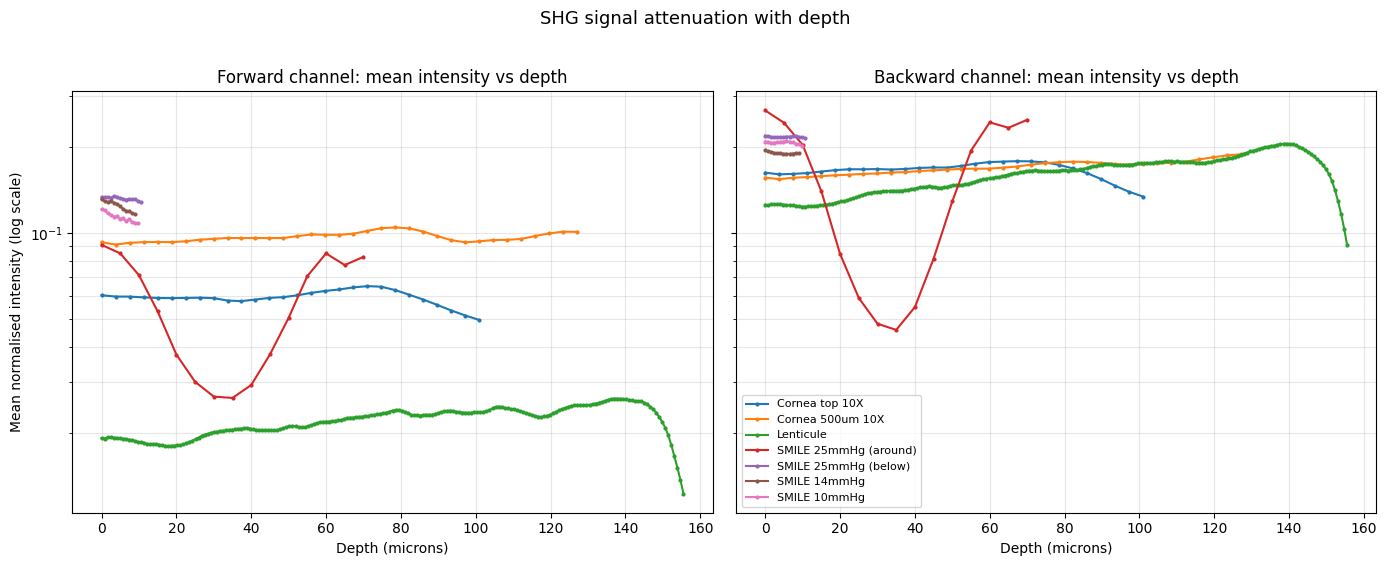

In [ ]:
# ---------------------------------------------------------------------------
# Intensity vs depth, forward and backward channels, all files.
# Log y-axis: exponential attenuation shows up as a straight line.
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt

colors = plt.cm.tab10.colors
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

for i, (label, d) in enumerate(results.items()):
    c = colors[i % len(colors)]
    axes[0].plot(d['depth'], d['fwd'], color=c, label=label, marker='.', ms=4)
    axes[1].plot(d['depth'], d['bwd'], color=c, label=label, marker='.', ms=4)

for ax, title in zip(axes, ['Forward channel', 'Backward channel']):
    ax.set_yscale('log')                       # straight line == exponential decay
    ax.set_xlabel('Depth (microns)')
    ax.set_title(f'{title}: mean intensity vs depth')
    ax.grid(True, which='both', alpha=0.3)

axes[0].set_ylabel('Mean normalised intensity (log scale)')
axes[1].legend(fontsize=8, loc='best')
plt.suptitle('SHG signal attenuation with depth', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

SMILE 25mmHg (around) - 5 um interval, spans the surgical plane

Forward: min at 35.0 um | intensity 0.0265 | baseline 0.0908 | 70.8% drop
Backward: min at 35.0 um | intensity 0.0458 | baseline 0.2677 | 82.9% drop

Minima separation: 0.0 um


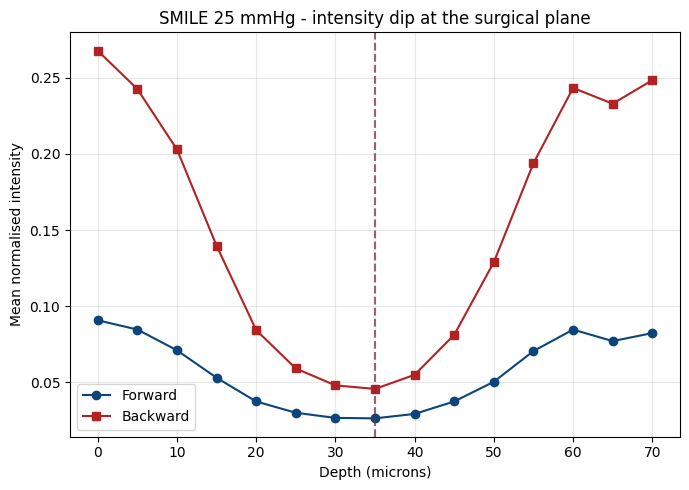

In [ ]:
# ---------------------------------------------------------------------------
# Quantify the intensity minimum in the SMILE 25mmHg (around) scan.
# The scan spans the SMILE surgical plane; a signal dip there would reflect
# collagen disruption at the cut. I locate the minimum in each channel and
# measure how deep the dip is relative to the surrounding tissue.
# ---------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

d = results['SMILE 25mmHg (around)']
depth, fwd, bwd = d['depth'], d['fwd'], d['bwd']

def describe_dip(depth, curve, name):
    i_min = np.argmin(curve)
    z_min = depth[i_min]
    baseline = curve.max()
    drop_pct = 100 * (baseline - curve[i_min]) / baseline
    print(f'{name}: min at {z_min:.1f} um | intensity {curve[i_min]:.4f} | baseline {baseline:.4f} | {drop_pct:.1f}% drop')
    return z_min

print('SMILE 25mmHg (around) - 5 um interval, spans the surgical plane\n')
fz = describe_dip(depth, fwd, 'Forward')
bz = describe_dip(depth, bwd, 'Backward')
print(f'\nMinima separation: {abs(fz - bz):.1f} um')

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(depth, fwd, 'o-', color='#0C447C', label='Forward')
ax.plot(depth, bwd, 's-', color='#B22222', label='Backward')
ax.axvline(fz, color='#0C447C', ls='--', alpha=0.5)
ax.axvline(bz, color='#B22222', ls='--', alpha=0.5)
ax.set_xlabel('Depth (microns)')
ax.set_ylabel('Mean normalised intensity')
ax.set_title('SMILE 25 mmHg - intensity dip at the surgical plane')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

saved: /content/drive/MyDrive/BEng_Project/intensity_analysis/smile_dip.png


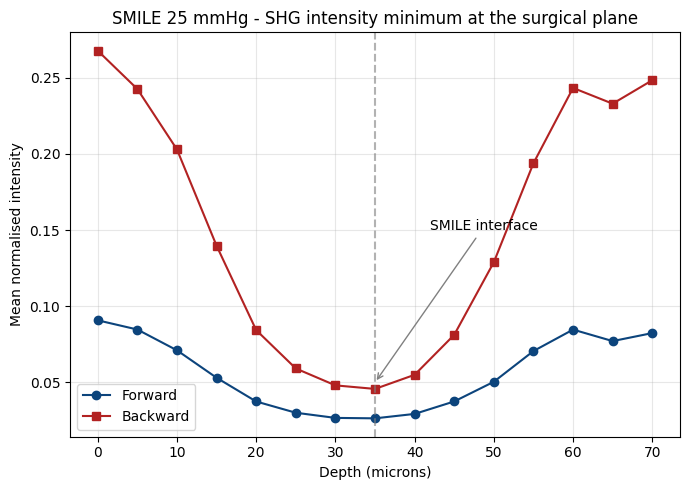

In [ ]:
# save both figures to Drive
import os
OUT = '/content/drive/MyDrive/BEng_Project/intensity_analysis/'
os.makedirs(OUT, exist_ok=True)

# re-draw and save the SMILE dip figure
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(depth, fwd, 'o-', color='#0C447C', label='Forward')
ax.plot(depth, bwd, 's-', color='#B22222', label='Backward')
ax.axvline(35, color='grey', ls='--', alpha=0.6)
ax.annotate('SMILE interface', xy=(35, 0.05), xytext=(42, 0.15),
            arrowprops=dict(arrowstyle='->', color='grey'))
ax.set_xlabel('Depth (microns)'); ax.set_ylabel('Mean normalised intensity')
ax.set_title('SMILE 25 mmHg - SHG intensity minimum at the surgical plane')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()
fig.savefig(OUT + 'smile_dip.png', dpi=200, bbox_inches='tight')
print('saved:', OUT + 'smile_dip.png')

In [2]:
## Part 2 — Raw (un-normalised) intensity analysis
# ---------------------------------------------------------------------------
# Everything above used the **normalised, percentile-clipped** patches — the data prepared for model training. That processing is fine for training, but clipping caps the brightest surface pixels, which can hide genuine attenuation and distort comparisons between the two channels.
# Here I re-run the intensity–depth analysis on the **raw `.tif` intensities**, before any normalisation, to test whether the findings (the signal dip at the SMILE plane, and the flatness of the cornea/lenticule stacks) hold up on the physically faithful data.
# This cell loads each raw `.tif` stack, extracts the backward (channel 2) and forward (channel 5) frames, and computes the mean intensity of the whole frame per z-slice — no patches, no normalisation.
# ---------------------------------------------------------------------------

import numpy as np, tifffile, matplotlib.pyplot as plt
TIF_DIR = '/content/drive/MyDrive/Colab Notebooks/'
BWD_CH, FWD_CH = 1, 4          # backward = ch2 (idx1), forward = ch5 (idx4)

FILES = {
 'F+B+lambda first 100 um top cornea 10X.tif': ('Cornea top 10X', 3.74),
 'F+B+Lambda starting from 500 um cornea 10x.tif': ('Cornea 500um 10X', 3.74),
 'Forward_backward_lambda_scan_lenticule.tif': ('Lenticule', 0.81),
 'SMILE 160 um - around the SMILE-  25 mmHg deflated to 23 (5 um interval).tif': ('SMILE 25mmHg (around)', 5.0),
 'SMILE 160 um - 50un right below the plane of the SMILE 25 mmHg deflated to 23 (0.81 um interval).tif': ('SMILE 25mmHg (below)', 0.81),
 'SMILE 160 um - 50un right below the plane of the SMILE 14 mmHg deflated to 14 (0.81 um interval).tif': ('SMILE 14mmHg', 0.81),
 'SMILE 160 um - 50un right below the plane of the SMILE 10 mmHg deflated to 8 (0.81 um interval).tif': ('SMILE 10mmHg', 0.81),
}

raw = {}
for fname, (label, iv) in FILES.items():
    img = np.squeeze(tifffile.imread(TIF_DIR + fname)).astype(np.float32)   # (Z, C, Y, X)
    Z = img.shape[0]
    bwd = img[:, BWD_CH].mean(axis=(1, 2))     # raw mean of whole frame, per slice
    fwd = img[:, FWD_CH].mean(axis=(1, 2))
    depth = np.arange(Z) * iv
    raw[label] = {'depth': depth, 'fwd': fwd, 'bwd': bwd}
    print(f'{label:<24} {Z} slices | fwd {fwd.min():.0f}-{fwd.max():.0f} | bwd {bwd.min():.0f}-{bwd.max():.0f}')

Cornea top 10X           28 slices | fwd 2375-3105 | bwd 12154-14855
Cornea 500um 10X         35 slices | fwd 1904-2159 | bwd 8727-9724
Lenticule                193 slices | fwd 853-1776 | bwd 9859-16863
SMILE 25mmHg (around)    15 slices | fwd 66-171 | bwd 7426-17752
SMILE 25mmHg (below)     14 slices | fwd 116-120 | bwd 12684-12799
SMILE 14mmHg             12 slices | fwd 90-98 | bwd 10765-10890
SMILE 10mmHg             13 slices | fwd 157-170 | bwd 16375-16663


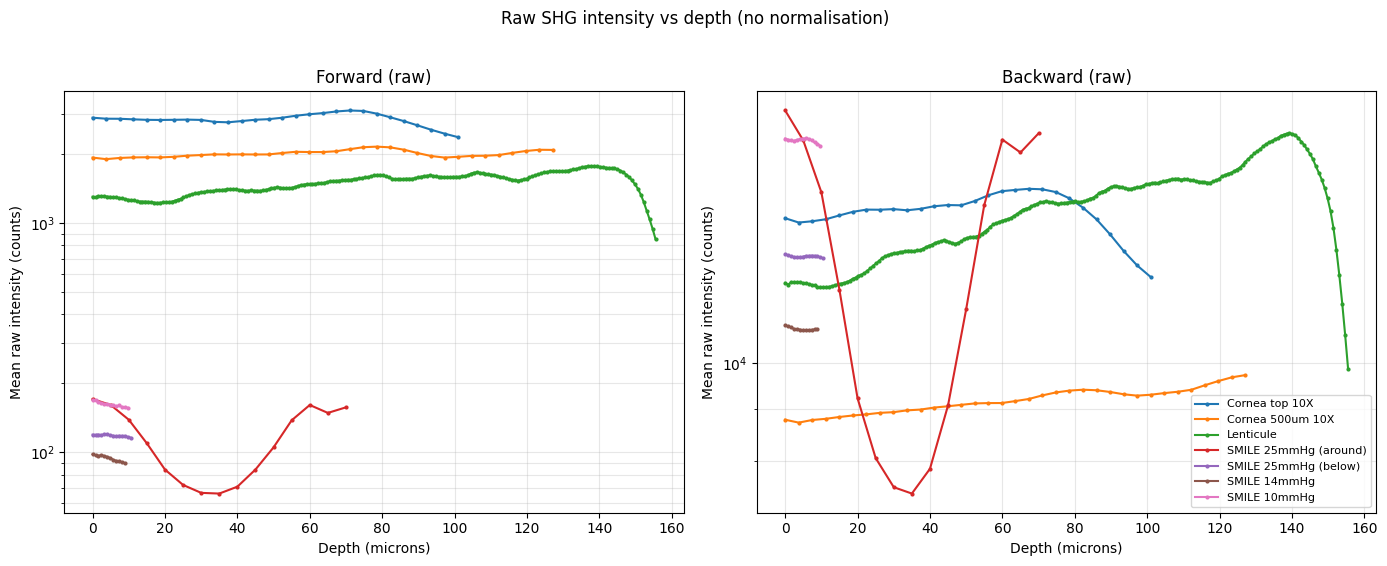

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
colors = plt.cm.tab10.colors
for i, (label, d) in enumerate(raw.items()):
    c = colors[i % 10]
    axes[0].plot(d['depth'], d['fwd'], '.-', color=c, label=label, ms=4)
    axes[1].plot(d['depth'], d['bwd'], '.-', color=c, label=label, ms=4)
for ax, title in zip(axes, ['Forward (raw)', 'Backward (raw)']):
    ax.set_yscale('log')
    ax.set_xlabel('Depth (microns)'); ax.set_ylabel('Mean raw intensity (counts)')
    ax.set_title(title); ax.grid(True, which='both', alpha=0.3)
axes[1].legend(fontsize=8)
plt.suptitle('Raw SHG intensity vs depth (no normalisation)', y=1.02)
plt.tight_layout(); plt.show()
fig.savefig(OUT + 'intensity_vs_depth_raw.png', dpi=200, bbox_inches='tight')

In [4]:
d = raw['SMILE 25mmHg (around)']
depth, fwd, bwd = d['depth'], d['fwd'], d['bwd']

def describe_dip(depth, curve, name):
    i_min = int(np.argmin(curve))
    z_min = depth[i_min]
    baseline = curve.max()
    drop_pct = 100 * (baseline - curve[i_min]) / baseline
    print(f'{name}: min at {z_min:.1f} um | intensity {curve[i_min]:.0f} | baseline {baseline:.0f} | {drop_pct:.1f}% drop')
    return z_min

fz = describe_dip(depth, fwd, 'Forward')
bz = describe_dip(depth, bwd, 'Backward')
print(f'Minima separation: {abs(fz - bz):.1f} um')

Forward: min at 35.0 um | intensity 66 | baseline 171 | 61.3% drop
Backward: min at 35.0 um | intensity 7426 | baseline 17752 | 58.2% drop
Minima separation: 0.0 um


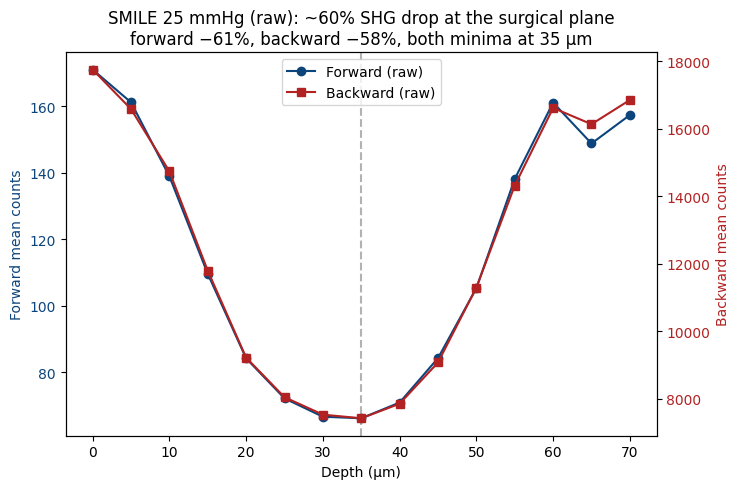

In [5]:
import os
OUT = '/content/drive/MyDrive/BEng_Project/intensity_analysis/'
os.makedirs(OUT, exist_ok=True)

fig, ax = plt.subplots(figsize=(7.5, 5))
l1, = ax.plot(depth, fwd, 'o-', color='#0C447C', label='Forward (raw)')
ax.set_xlabel('Depth (µm)'); ax.set_ylabel('Forward mean counts', color='#0C447C')
ax.tick_params(axis='y', labelcolor='#0C447C')
ax2 = ax.twinx()
l2, = ax2.plot(depth, bwd, 's-', color='#B22222', label='Backward (raw)')
ax2.set_ylabel('Backward mean counts', color='#B22222')
ax2.tick_params(axis='y', labelcolor='#B22222')
ax.axvline(35, color='grey', ls='--', alpha=0.6)
ax.set_title('SMILE 25 mmHg (raw): ~60% SHG drop at the surgical plane\nforward −61%, backward −58%, both minima at 35 µm')
ax.legend(handles=[l1, l2], loc='upper center')
fig.tight_layout()
fig.savefig(OUT + 'smile_dip_raw.png', dpi=200, bbox_inches='tight')
plt.show()